In [1]:
import warnings
warnings.filterwarnings("ignore")    

In [2]:
#from matplotlib.colors import ListedColormap
import squidpy as sq
#import spatialdata as sd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
#import squidpy as sq
import anndata as ad

import warnings
import pickle
  

In [3]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_inc_relapse_webportal.h5ad'

adata=sc.read_h5ad(PATH)
adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')



In [4]:
adata_5k.obs["Site_status"].value_counts()

Site_status
Lesional                            205785
Non-lesional                        192952
3D_Week12                           180311
3D_Lesional_baseline                153479
Week 12                             149280
Remission_longterm (past)           140285
Remission_longterm (never)          127032
Relapse                             102198
Psoriasis_replicate_non-lesional     76048
Week 8 Psoriasis                     72094
Remission_longterm (week 8)          71279
Psoriasis_replicate_Lesional         60647
Healthy                              59315
Psoriasis_replicate_PostRx           49385
Day 14_HF                            30438
Name: count, dtype: int64

In [5]:
# exclude fibroblasts as error
adata_5k= adata_5k[adata_5k.obs['lvl5_annotation']!="F1: Superficial"].copy()

In [6]:

RENAME = {"ILC3_CCL1+PTGDS+": "ILC3"}
adata_5k.obs["tmp"]=adata_5k.obs["lvl5_annotation"].map(RENAME)
adata_5k.obs["lvl5_annotation"]=adata_5k.obs["tmp"].fillna(adata_5k.obs["lvl5_annotation"])

adata_5k.obs['lvl5_annotation'] = adata_5k.obs['lvl5_annotation'].astype('category')



In [7]:
# colors = {'Adipocyte': '#B8860B',
#  'F1: Superficial': '#FFFFE4',
#  'F1: Regenerative': '#FFFFE4',
#  'F2/3: Perivascular': '#78b5d7',
#  'F2: Universal': '#d0e1f2',
#  'F3: FRC-like': '#fbd4d7',
#  'F4: DS_DPEP1+': '#6A728B',
#  'F4: TNN+COCH+': '#bad6ea',
#  'F5: NGFR+': '#788bd2',
#  'F5: RAMP1+': '#9e99c9',
#  'F6: Inflammatory myofibroblast': '#00ffff',
#  'KC1/2': '#505aa1',
#  'KC2/3_cycling': '#007FFF',
#  'KC_cycling': '#007FFF',
#  'KC3': '#839edd',
#  'KC4': '#b1dae6',
#  'KC5': '#272c5f',


#  'MigDC (cDC2)': '#00FF00',
#  'MigDC (cDC1)': '#FF9999',

#  'Tnaive': '#F9F2E4',
#  'Treg':  '#505aa1',
#  'Treg_LRRC32+': '#FF00FF', # '#e0c5d2', # '#FF00FF', #'#ff5e00',
#  'VE2': '#9f1a1a',
#  'VE': '#9f1a1a',
#  'VE1_Art': '#660000',
#  'VE3_Ven': '#764869',
#  'VE4_Cap': '#FFB6C1',
#  'VE3_Ven_APLN+': '#FF073A',
#  'cDC1': '#ac1d5c',
#  'cDC2': '#6F478C',
#  'cDC2: MMP12hi': '#f71886',
#  'mSchwann': '#555555',
#  'nmSchwann': '#999999',
#  'pDC': '#D85B8C',
#  'cDC2: EREG+CCR7+': '#7B8B43',

#  'ILC1': '#FFFF00',
#  'ILC1_NCR2+P2RX7+': '#c18bcb',
#  'ILC1_NK': '#F4D03F',
#  'ILC1/NK': '#F4D03F',
#  'ILC2': '#F1C40F',
#  'ILC2/3': '#F1C40F',
#  'ILC3': '#ff68b4', #'#C79A00',
#  'ILC3 CCL1+PTGDS+': '#ff68b4',
#  'ILC3_CCL1+PTGDS+': '#ff68b4',
#  'ILC_Prolif': '#3F3100',
#  'ILC_prolif': '#3F3100',
#  'KC1': '#3a4e7a',
#  'KC2': '#505aa1',
#  'KC_HF: ORS_cycling': '#267326',
#  'KC_HF: Basal_NPNT+': '#006400',
#  'KC_HF': '#006400',
#  'KCinflamm_basal': '#f9f3fb',
#  'KCinflamm': '#f9f3fb',
#  'KCinflamm_int/late': '#e9c8dc',
#  'KCinflamm_cycling': '#e0c5d2',
#  'KC1-2_cycling': '#e0c5d2',
#  'KCinflamm_int': '#f5d3e7',
#  'LC_CCR7+': '#3bc1a4',
#  'Mac1': '#6A3F9B',
#  'Mac_CX3CR1+': '#9D1A80',
#  'Mac_TREM2+LPL+': '#D2C5E1',
#  'Merkel cell': '#2f2f2f',
#  'MoDC': '#7F00A2',
#  'MoDC/cDC2: MMP12+': '#7F00A2',
#  'MoDC/cDC2': '#7F00A2',
#  'Monocyte': '#D8A7FF',
#  'Mono CD16+': '#E1C6FF',
#  'NK': '#FF00FF',
#  'Neutrophil': '#4D3F8C',
#  'Satellite cell': '#F387C7',
#  'Skeletal muscle': '#F14D8E',
#  'Tc_IFNGhi': '#F5A600',
#  'Tc3_IFNGhi': '#F5A600',
#  'TRM_IL13+': '#7795cc',
#  'TRM_IL17+': '#E63238',
#  'Tc_ZNF683+': '#D4B082',
#  'Th': '#F9CA67',
#  'Th_PPARGhi': '#FAE064',
#  'Th_CXCR6+': '#F48B50',
#  'TR1': '#E3F2DC',
#  'cDC2: IL1B+': '#B78FE1',
#  'cDC2_cycling': '#9272B4',
#  'Eosinophil': '#FF5F00',
#  'Mechanoreceptor ASIC2+': '#D3D3D3',
#  'ASIC2+_Mechanoreceptor': '#D3D3D3',
#  'Tc_γδ': '#28c1d0',
#  'T_γδ': '#28c1d0',
#  'Tc0': '#5a1f16',
#  'Th_PPARGhi_IL17': '#FFE064',
#  'Tfh-like': '#d8e4e2',

#  'Other': '#F3F3F3',

         
#          }

file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

# Load the dict back
with open(file_path, 'rb') as file:
    colors = pickle.load(file)
colors=colors|{'ILC3': '#ff68b4', }
 
adata_5k.obs['lvl5_annotation'] =adata_5k.obs['lvl5_annotation'] .astype('category')
adata_5k.uns['lvl5_annotation_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['lvl5_annotation'].cat.categories]




In [8]:
[x for x in adata_5k.obs["lvl5_annotation"].unique() if x.startswith("ILC3")]

['ILC3']

In [9]:
NICHE='niche19'

In [10]:
# #adata_filtered = adata_5k[adata_5k.obs["niche12"].str.startswith("Tzone")]
# adata_filtered = adata_5k[adata_5k.obs["Site_status"].str.startswith("Les")]

# sample_counts = adata_filtered.obs["info_id6"].value_counts()
# valid_samples = sample_counts[sample_counts > 10].index
# #KEEP = ["Lesional", "Lesional Baseline"]
# adata_filtered.obs["Site_status"].value_counts()
# adata_filtered = adata_filtered[adata_filtered.obs[NICHE]=="Tzone-like"]
# adata_filtered.obs[NICHE].value_counts()

In [11]:
# adata_filtered.obs["disease_overall"].value_counts()


In [12]:
# adata_filtered.obs["Site_status"].value_counts()

In [13]:
# # Get counts per cluster
# counts = adata_filtered.obs["lvl5_annotation"].value_counts()

# # Keep only clusters with at least 5 cells
# keep_clusters = counts[counts >= 5].index

# # Subset your AnnData
# adata_filtered = adata_filtered[adata_filtered.obs["lvl5_annotation"].isin(keep_clusters)].copy()

# print("Remaining clusters:", adata_filtered.obs["lvl5_annotation"].unique())

In [14]:
# adata_filtered.shape

In [15]:
# for x in ["AD"]:
#     adata_filtered2=adata_filtered[adata_filtered.obs["disease_overall"]==x]
#     print(adata_filtered2.shape)
#     counts = adata_filtered2.obs["lvl5_annotation"].value_counts()

#     # Keep only clusters with at least 5 cells


In [16]:
# keep_clusters = counts[counts >= 10].index

# adata_filtered2 = adata_filtered2[adata_filtered2.obs['lvl5_annotation'].isin(keep_clusters)].copy()

In [17]:

# adata_filtered2.shape
# sq.gr.spatial_neighbors(adata_filtered2, 
#                         coord_type="generic",
#                         radius=10,
#                        )  
# sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")
# sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward")


# sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
# sq.pl.co_occurrence(
#     adata_filtered2,
#     cluster_key="lvl5_annotation",
#     clusters="MigDC (cDC2)",
#     figsize=(20, 20),
#     #percentile=0.9
# )
# print("done")


In [18]:
# sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward",
#                       vmax=5,
#                            save="Tzone_interactionmatrix_AD.pdf"

#                       )



In [19]:
# for x in ["Psoriasis"]:
#     adata_filtered2=adata_filtered[adata_filtered.obs["disease_overall"]==x]
#     # Get counts per cluster
#     counts = adata_filtered2.obs["lvl5_annotation"].value_counts()

#     # Keep only clusters with at least 5 cells
#     keep_clusters = counts[counts >= 10].index

#     # Subset your AnnData
#     adata_filtered2 = adata_filtered2[adata_filtered2.obs["lvl5_annotation"].isin(keep_clusters)].copy()

#     sq.gr.spatial_neighbors(adata_filtered2, coord_type="generic",
#                             radius=10,
#                            )
#     sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")
#     sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward")
    
    
#     sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
#     sq.pl.co_occurrence(
#         adata_filtered2,
#         cluster_key="lvl5_annotation",
#         clusters="MigDC (cDC2)",
#         figsize=(20, 20),
#     )
#     print("done")

In [20]:
# sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward",
#                       vmax=5,
#                            save="Tzone_interactionmatrix_PSO.pdf"

#                       )


# week 12 migdc

In [21]:
# #adata_filtered = adata_5k[adata_5k.obs["niche12"].str.startswith("Tzone")]
# adata_filtered = adata_5k[adata_5k.obs["Site_status"].str.startswith("Week 12")]

# sample_counts = adata_filtered.obs["info_id6"].value_counts()
# valid_samples = sample_counts[sample_counts > 10].index
# #KEEP = ["Lesional", "Lesional Baseline"]
# adata_filtered.obs["Site_status"].value_counts()
# adata_filtered = adata_filtered[adata_filtered.obs[NICHE]=="Tzone-like"]
# adata_filtered.obs[NICHE].value_counts()

In [22]:
# for x in ["AD"]:
#     adata_filtered2=adata_filtered[adata_filtered.obs["disease_overall"]==x]
#     print(adata_filtered2.shape)
#     counts = adata_filtered2.obs["lvl5_annotation"].value_counts()

#     # Keep only clusters with at least 5 cells
# keep_clusters = counts[counts >= 5].index

# adata_filtered2 = adata_filtered2[adata_filtered2.obs['lvl5_annotation'].isin(keep_clusters)].copy()
# adata_filtered2.shape
# sq.gr.spatial_neighbors(adata_filtered2, 
#                         coord_type="generic",
#                         radius=10,
#                        )  
# sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")
# sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="average")


# sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
# sq.pl.co_occurrence(
#     adata_filtered2,
#     cluster_key="lvl5_annotation",
#     clusters="MigDC (cDC2)",
#     figsize=(20, 20),
#     #percentile=0.9
# )
# print("done")
# sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward",
#                       vmax=5,
#                            save="Tzone_interactionmatrix_AD_W12.pdf"

#                       )


In [23]:

# # # sq.pl.co_occurrence(
# # #     adata_filtered2,
# # #     cluster_key="lvl5_annotation",
# # #     clusters="Treg_LRRC32+",
# # #     figsize=(20, 20),
# # #     #percentile=0.9
# # # )
# # sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation",
         
# #                       )

# # print("done")
# sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", 
#                        method="average",
#                       vmax=8,
#                                     cmap="Reds"
#                       )

In [24]:
# sq.pl.co_occurrence(adata_filtered2, 
#                     cluster_key="lvl5_annotation",
#                     clusters="Treg_LRRC32+", 
#                     figsize=(30, 30))
# # sq.pl.co_occurrence(adata_filtered2, 
# #                     cluster_key="lvl5_annotation",
# #                     clusters="Treg_LRRC32+", 
# #                     figsize=(22, 22))
# sq.pl.co_occurrence(adata_filtered2, 
#                     cluster_key="lvl5_annotation",
#                     clusters="MigDC (cDC2)", 
#                     figsize=(30, 30))
# # sq.pl.co_occurrence(adata_filtered2, 
# #                     cluster_key="lvl5_annotation",
# #                     clusters="Treg_LRRC32+", 
# #                     figsize=(22, 22))


# trm

In [25]:
# adata.obs["Site_status"].value_counts()

In [26]:
adata=adata_5k



In [27]:

#adata_filtered = adata_5k[adata_5k.obs["niche12"].str.startswith("Tzone")]
#adata_filtered = adata_5k[adata_5k.obs["Site_status"].str.startswith("Les")]
NICHE="niche19"
adata_filtered=adata[adata.obs["disease_overall"]=="AD"]
adata_filtered=adata_filtered[adata_filtered.obs[NICHE].str.startswith("Epid")]

sample_counts = adata_filtered.obs["info_id6"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
#KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered.obs["Site_status"].value_counts()
#adata_filtered = adata_filtered[adata_filtered.obs[NICHE]=="Sebaceous_immune"]
adata_filtered.obs[NICHE].value_counts()

niche19
Epidermis_mid              117907
Epidermis_basal             88084
Epidermis_upper             81057
EpidermisInflamm_mid        26966
Epidermis_basal_cycling     10378
Epidermis_APChi               645
EpidermisInflamm_upper        468
Name: count, dtype: int64

In [28]:
adata_filtered2=adata_filtered[(adata_filtered.obs["Site_status"].str.startswith("Les"))|
                              (adata_filtered.obs["Site_status"].str.startswith("3D_Lesional_baseline"))
                              
                              ]
counts = adata_filtered2.obs["lvl5_annotation"].value_counts()
keep_clusters = counts[counts >= 20].index
adata_filtered2 = adata_filtered2[adata_filtered2.obs["lvl5_annotation"].isin(keep_clusters)].copy()
adata_filtered2.obs["lvl5_annotation"].value_counts()

lvl5_annotation
KC3                          47886
KC1                          21985
KC5                          10743
KC1-2_cycling                 8648
KC2/3_cycling                 3965
KCinflamm_basal               2375
KC                            2185
Melanocyte                    1978
LC                            1341
TRM_IL13+                     1251
KCinflamm_int/late             685
KC2                            613
cDC2: EREG+CCR7+               441
cDC2: MMP12hi                  408
KC4                            199
cDC1                           198
T                              184
KC_Sebocyte_DuctOuter          141
MigDC (cDC2)                   113
T_Prolif                        70
ILC3                            66
Sweat gland channel outer       60
KC_Sebocyte_DuctInner           59
cDC2                            51
Treg                            39
Th                              33
Tnaive                          25
Pericyte1                       22
Name

In [29]:

# adata_filtered2.obs['lvl5_annotation'] = adata_filtered2.obs['lvl5_annotation'].astype('category')



In [30]:
# adata_filtered2.obs["lvl5_annotation"].value_counts()

In [31]:
import gc
gc.collect()

1153

In [32]:

sq.gr.spatial_neighbors(adata_filtered2, 
                        coord_type="generic",
                        radius=10,
                       )  
sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")




100%|██████████| 1000/1000 [00:04<00:00, 215.56/s]


lesional


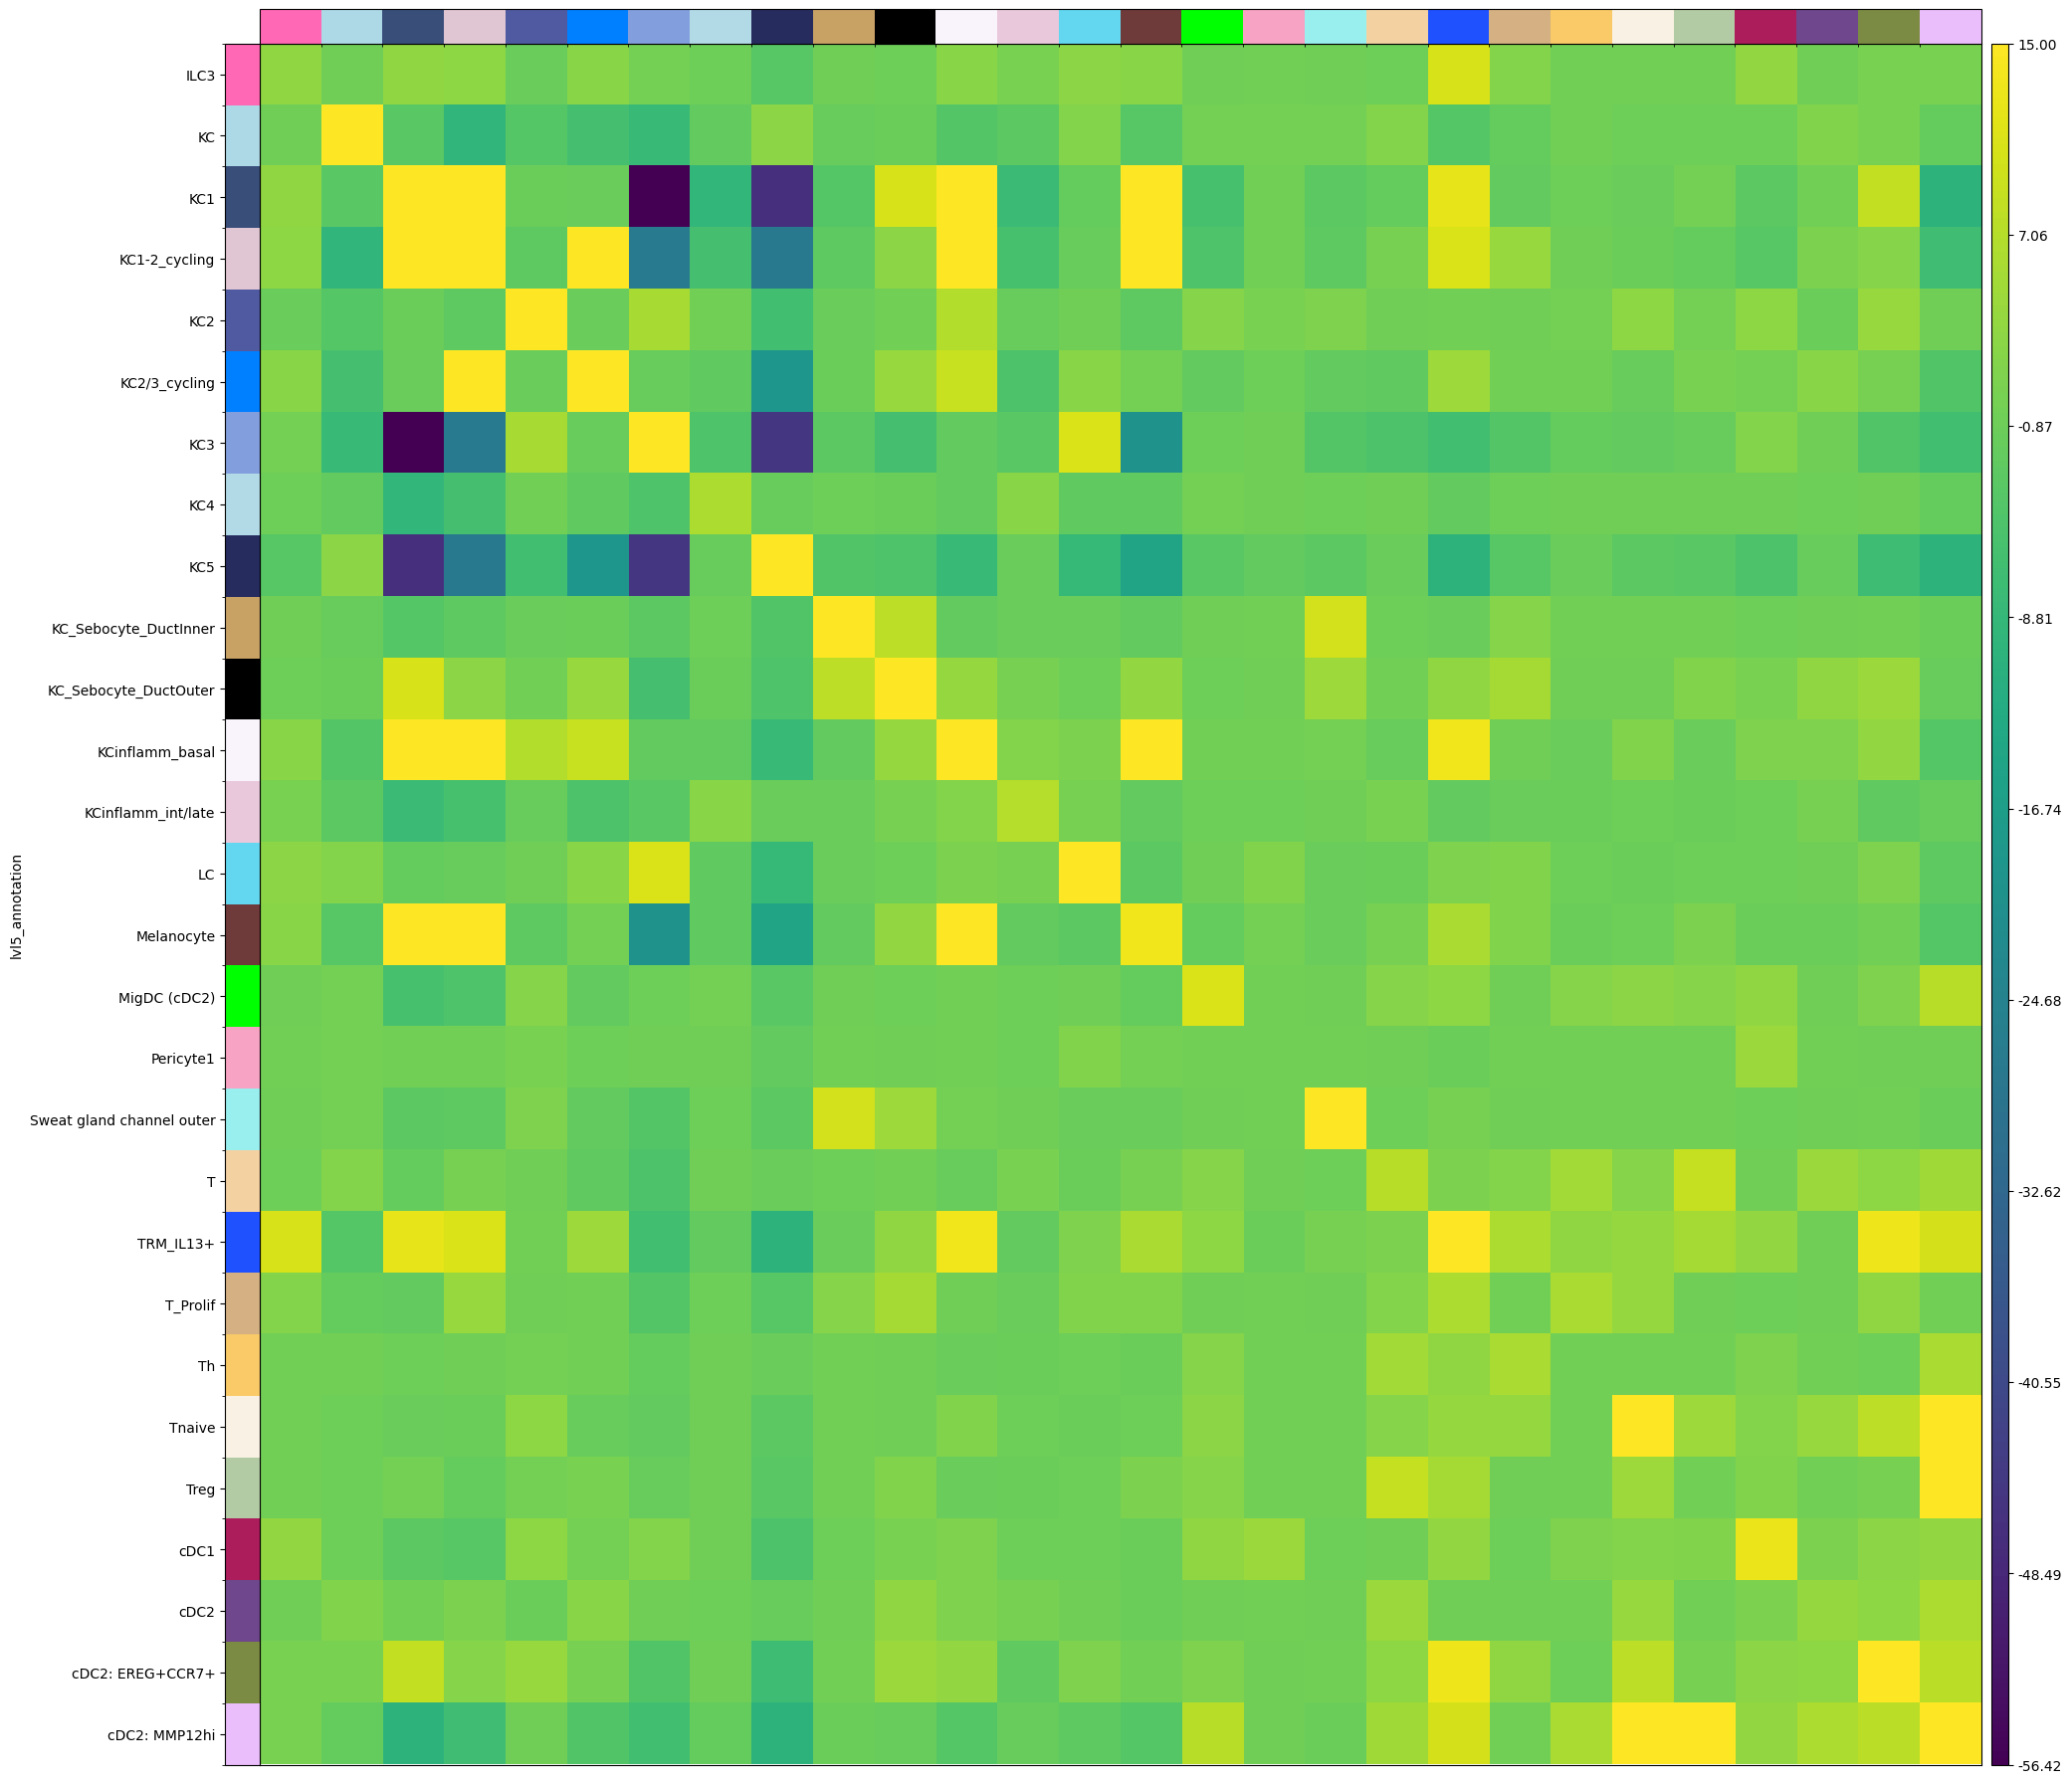

In [33]:

print("lesional")

sq.pl.nhood_enrichment(adata_filtered2, 
                       cluster_key="lvl5_annotation",
                       method=None,
                      vmax=15,
                       title='',
                          #cmap="Reds"
                                             save="baseline_coloc.pdf")
                          

In [34]:
# STOP

In [35]:
9

9

In [36]:
# stop

In [37]:
# adata_filtered2=adata_filtered[(adata_filtered.obs["Site_status"].str.startswith("Les"))|
#                               (adata_filtered.obs["Site_status"].str.startswith("3D_Lesional_baseline"))
                              
#                               ]
# counts = adata_filtered2.obs["lvl5_annotation"].value_counts()
# keep_clusters = counts[counts >= 10].index
# adata_filtered2 = adata_filtered2[adata_filtered2.obs["lvl5_annotation"].isin(keep_clusters)].copy()
# adata_filtered2.obs["lvl5_annotation"].value_counts()

In [38]:
adata_filtered2=adata_filtered[adata_filtered.obs["Site_status"].str.startswith("Week")]
counts = adata_filtered2.obs["lvl5_annotation"].value_counts()
keep_clusters = counts[counts >= 10].index
adata_filtered2 = adata_filtered2[adata_filtered2.obs["lvl5_annotation"].isin(keep_clusters)].copy()
print(adata_filtered2.shape)
# adata_filtered2.obs["lvl5_annotation"].value_counts()
# RENAME = {"ILC3_CCL1+PTGDS+": "ILC3"}
# adata_filtered2.obs["tmp"]=adata_filtered2.obs["lvl5_annotation"].map(RENAME)
# adata_filtered2.obs["lvl5_annotation"]=adata_filtered2.obs["tmp"].fillna(adata_filtered2.obs["lvl5_annotation"])

# adata_filtered2.obs['lvl5_annotation'] = adata_filtered2.obs['lvl5_annotation'].astype('category')


(51129, 4993)


In [39]:

# adata_filtered2.obs['lvl5_annotation'] = adata_filtered2.obs['lvl5_annotation'].astype('category')



In [40]:
sq.gr.spatial_neighbors(adata_filtered2, coord_type="generic")
sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")



100%|██████████| 1000/1000 [00:02<00:00, 469.99/s]


week12


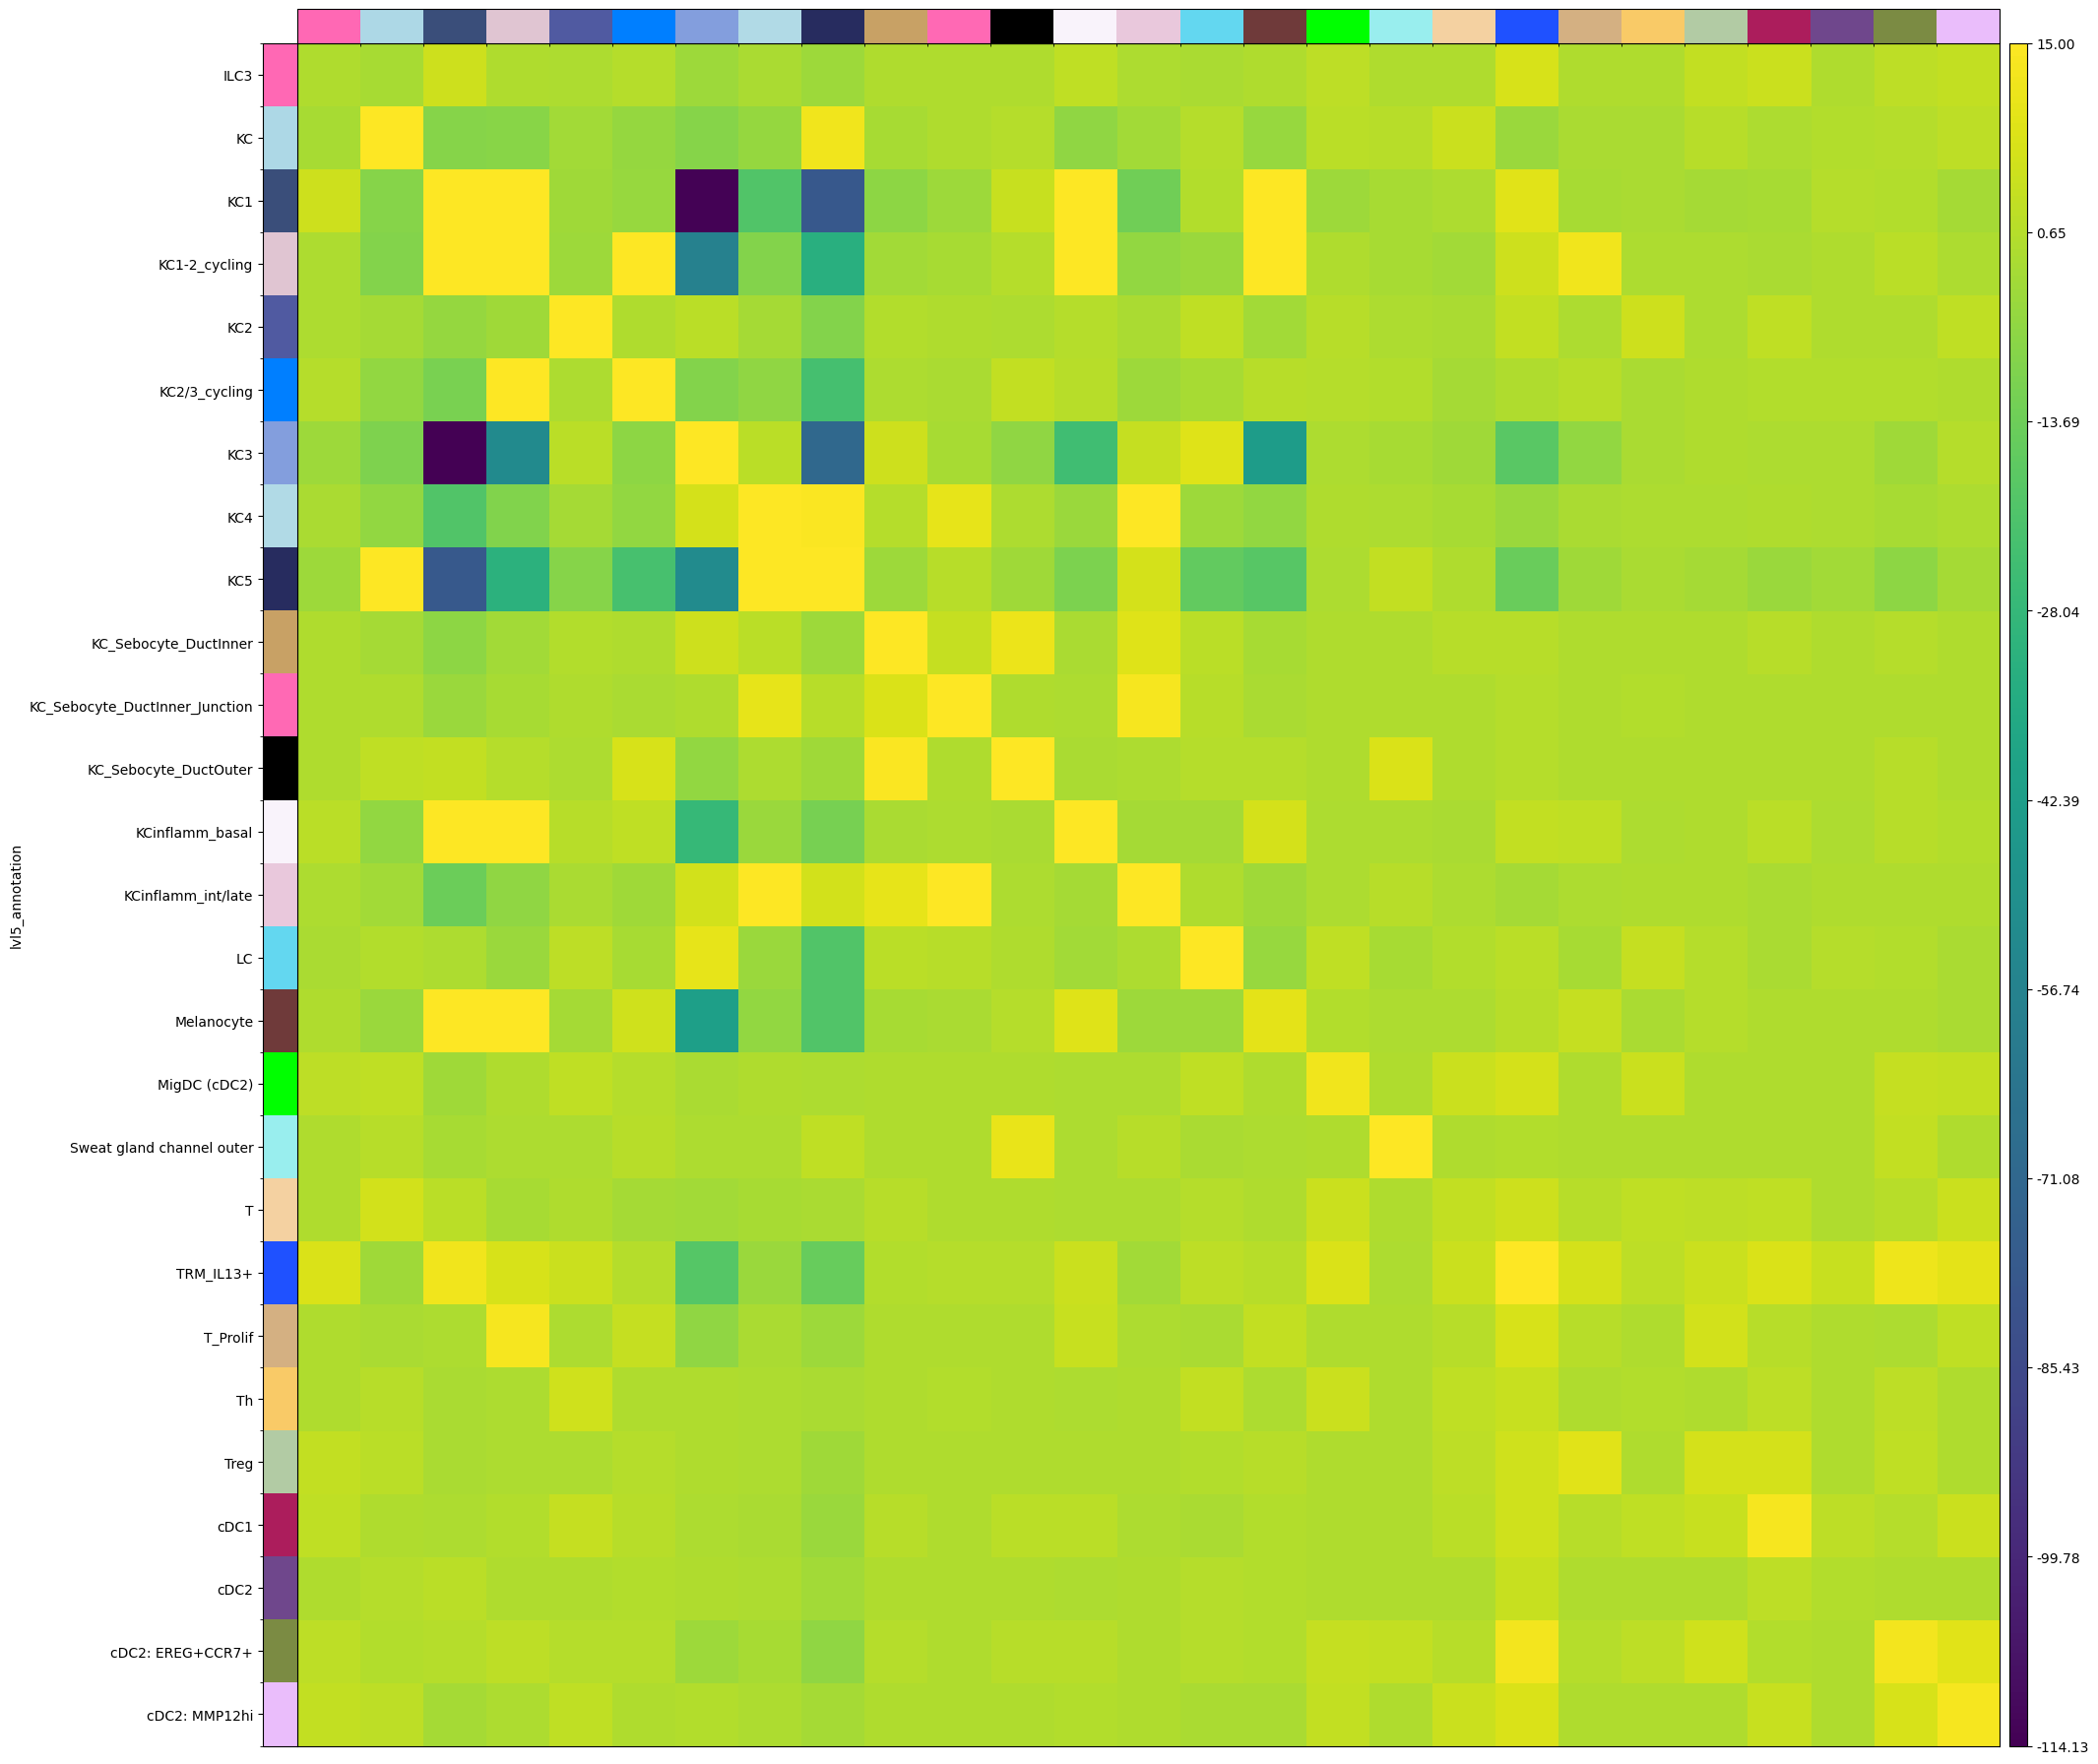

In [41]:
print("week12")
sq.pl.nhood_enrichment(adata_filtered2, 
                       cluster_key="lvl5_annotation",
                       method=None,
                      vmax=15,
                                              title='',

                      save="week12_coloc.pdf")

In [42]:
STOP



# sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
# sq.pl.co_occurrence(
#     adata_filtered2,
#     cluster_key="lvl5_annotation",
#     clusters="TRM_IL13+",
#     figsize=(20, 20),
# )
# print("done")

NameError: name 'STOP' is not defined

In [ ]:
adata_filtered2=adata_filtered[adata_filtered.obs["Site_status"].str.startswith("Non")]
counts = adata_filtered2.obs["lvl5_annotation"].value_counts()
keep_clusters = counts[counts >= 10].index
adata_filtered2 = adata_filtered2[adata_filtered2.obs["lvl5_annotation"].isin(keep_clusters)].copy()
print(adata_filtered2.shape)
RENAME = {"ILC3_CCL1+PTGDS+": "ILC3"}
adata_filtered2.obs["tmp"]=adata_filtered2.obs["lvl5_annotation"].map(RENAME)
adata_filtered2.obs["lvl5_annotation"]=adata_filtered2.obs["tmp"].fillna(adata_filtered2.obs["lvl5_annotation"])



sq.gr.spatial_neighbors(adata_filtered2, coord_type="generic")
sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")
#sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward")


# sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
# sq.pl.co_occurrence(
#     adata_filtered2,
#     cluster_key="lvl5_annotation",
#     clusters="TRM_IL13+",
#     figsize=(20, 20),
# )
# print("done")

In [ ]:
print("non-lesional")
sq.pl.nhood_enrichment(adata_filtered2, 
                       cluster_key="lvl5_annotation",
                       method=None,
                      vmax=15)

In [ ]:
print("non-lesional")
sq.pl.nhood_enrichment(adata_filtered2, 
                       cluster_key="lvl5_annotation",
                       method='normal',
                      vmax=15)

In [ ]:
    save="Tzone_interactionmatrix_AD.pdf"


In [ ]:
for x in ["AD"]:
    adata_filtered2=adata_filtered[adata_filtered.obs["disease_overall"]==x]
    print(adata_filtered2.shape)
    # filter
    counts = adata_filtered2.obs["lvl5_annotation"].value_counts()
    keep_clusters = counts[counts >= 10].index
    adata_filtered2 = adata_filtered2[adata_filtered2.obs["lvl5_annotation"].isin(keep_clusters)].copy()
    print(adata_filtered2.shape)

    sq.gr.spatial_neighbors(adata_filtered2, coord_type="generic")
    sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")
    sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward")
    
    
    sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
    sq.pl.co_occurrence(
        adata_filtered2,
        cluster_key="lvl5_annotation",
        clusters="TRM_IL13+",
        figsize=(20, 20),
    )
    print("done")

In [ ]:
adata_filtered2.obs.lvl4_annotation.value_counts()

In [ ]:
#adata_filtered = adata_5k[adata_5k.obs["niche12"].str.startswith("Tzone")]
adata_filtered = adata_5k[adata_5k.obs["Site_status"].str.startswith("Les")]

sample_counts = adata_filtered.obs["info_id6"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
#KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered.obs["Site_status"].value_counts()
adata_filtered = adata_filtered[adata_filtered.obs[NICHE]=="Sebaceous_immune"]
adata_filtered.obs[NICHE].value_counts()

In [ ]:
for x in ["AD"]:
    adata_filtered2=adata_filtered[adata_filtered.obs["disease_overall"]==x]
    print(adata_filtered2.shape)
    counts = adata_filtered2.obs["lvl5_annotation"].value_counts()

    # Keep only clusters with at least 5 cells
keep_clusters = counts[counts >= 5].index

adata_filtered2 = adata_filtered2[adata_filtered2.obs['lvl5_annotation'].isin(keep_clusters)].copy()
adata_filtered2.shape
sq.gr.spatial_neighbors(adata_filtered2, 
                        coord_type="generic",
                        radius=10,
                       )  
sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")
sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward")


sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
sq.pl.co_occurrence(
    adata_filtered2,
    cluster_key="lvl5_annotation",
    clusters="MigDC (cDC2)",
    figsize=(20, 20),
    #percentile=0.9
)
print("done")
sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward",
                      vmax=5,
                      )


In [ ]:
# # for x in ["AD"]:
# #     adata_filtered2=adata_filtered[adata_filtered.obs["disease_overall"]==x]
# #     print(adata_filtered2.shape)
# #     # filter
# #     counts = adata_filtered2.obs["lvl4_annotation"].value_counts()
# #     keep_clusters = counts[counts >= 10 ].index
# #     adata_filtered2 = adata_filtered2[adata_filtered2.obs["lvl4_annotation"].isin(keep_clusters)].copy()
# #     print(adata_filtered2.shape)

# #     sq.gr.spatial_neighbors(adata_filtered2, coord_type="generic")
# #     sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl4_annotation")
# #     sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl4_annotation", method="ward")


# sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
# sq.pl.co_occurrence(
#     adata_filtered2,
#     cluster_key="lvl5_annotation",
#     clusters="ILC3_CCL1+PTGDS+",
#     figsize=(20, 20),
# )
# print("done")

In [ ]:
#adata_filtered = adata_5k[adata_5k.obs["niche12"].str.startswith("Tzone")]
adata_filtered = adata_5k[adata_5k.obs["Site_status"].str.startswith("Les")]

sample_counts = adata_filtered.obs["info_id6"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
#KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered.obs["Site_status"].value_counts()
adata_filtered = adata_filtered[adata_filtered.obs[NICHE]=="Epidermis_mid2"]
adata_filtered.obs[NICHE].value_counts()

In [ ]:
for x in ["Psoriasis"]:
    adata_filtered2=adata_filtered[adata_filtered.obs["disease_overall"]==x]
    print(adata_filtered2.shape)
    counts = adata_filtered2.obs["lvl5_annotation"].value_counts()

    # Keep only clusters with at least 5 cells
    keep_clusters = counts[counts >= 5].index

    # Subset your AnnData
    adata_filtered2 = adata_filtered2[adata_filtered2.obs["lvl5_annotation"].isin(keep_clusters)].copy()
    sq.gr.spatial_neighbors(adata_filtered2, coord_type="generic")
    sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")
    sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward")
    
    
    sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
    sq.pl.co_occurrence(
        adata_filtered2,
        cluster_key="lvl5_annotation",
        clusters="TRM_IL17+",
        figsize=(20, 20),
        cmap="Reds"
    )
    print("done")

In [ ]:
sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward",
    cmap="Reds",
    vmax=20
)
print("done")

# perineural

In [ ]:
#adata_filtered = adata_5k[adata_5k.obs["niche12"].str.startswith("Tzone")]
adata_filtered = adata_5k#[adata_5k.obs["Site_status"].str.startswith("Les")]

sample_counts = adata_filtered.obs["info_id6"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
#KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered.obs["Site_status"].value_counts()
adata_filtered = adata_filtered[adata_filtered.obs[NICHE]=="Perineural"]
adata_filtered.obs[NICHE].value_counts()
adata_filtered

In [ ]:
adata_filtered2=adata_filtered
print(adata_filtered2.shape)
counts = adata_filtered2.obs["lvl5_annotation"].value_counts()

# Keep only clusters with at least 5 cells
keep_clusters = counts[counts >= 5].index

# Subset your AnnData
adata_filtered2 = adata_filtered2[adata_filtered2.obs["lvl5_annotation"].isin(keep_clusters)].copy()
sq.gr.spatial_neighbors(adata_filtered2, coord_type="generic")
sq.gr.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation")
sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", method="ward")




In [ ]:
sq.pl.nhood_enrichment(adata_filtered2, cluster_key="lvl5_annotation", 
                       method="ward",
                      vmax=10,
                       cmap="Reds"
                      )


In [ ]:
sq.gr.co_occurrence(adata_filtered2, cluster_key="lvl5_annotation")
sq.pl.co_occurrence(
    adata_filtered2,
    cluster_key="lvl5_annotation",
    clusters="Mac_CX3CR1+",
    figsize=(20, 20),
    cmap="Reds"
)
print("done")

In [ ]:
STOP

In [ ]:
1

In [ ]:
for x in [ "Psoriasis"]:
    adata_filtered=adata_filtered[adata_filtered.obs["disease_overall"]==x]
    print(adata_filtered.shape)
    sq.gr.spatial_neighbors(adata_filtered, coord_type="generic")
    sq.gr.nhood_enrichment(adata_filtered, cluster_key="scanvi_predictions")
    sq.pl.nhood_enrichment(adata_filtered, cluster_key="scanvi_predictions", method="ward")
    
    
    sq.gr.co_occurrence(adata_filtered, cluster_key="scanvi_predictions")
    sq.pl.co_occurrence(
        adata_filtered,
        cluster_key="scanvi_predictions",
        clusters="MigDC (cDC2)",
        figsize=(10, 5),
    )
    print("done")

In [ ]:
#FILE_NAME = "adata_scrna_v3.h5ad.final"
FILE_NAME = "adata_scrna_freeze.h5ad"
PATH2=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
# adata.write(f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}')
adata=sc.read_h5ad(PATH2)
# try:
#     adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_scrna_v1.h5ad.final')
# except:
#     import scanpy as sc
#     adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_scrna_v1.h5ad.final')

adata.obs["lvl5_annotation_new"]=adata.obs["lvl4_annotation"]

# #adata=adata[adata.obs["tech"]!="xenium"]
# adata

adata

 

In [ ]:
# colors = {'Adipocyte': '#B8860B',
#  'F1: Superficial': '#FFFFE4',
#  'F1: Regenerative': '#FFFFE4',
#  'F2/3: Perivascular': '#78b5d7',
#  'F2: Universal': '#d0e1f2',
#  'F3: FRC-like': '#fbd4d7',
#  'F4: DS_DPEP1+': '#d3eec9',
#  'F4: TNN+COCH+': '#80ca80',
#  'F5: NGFR+': '#788bd2',
#  'F5: RAMP1+': '#9e99c9',
#  'F6: Inflammatory myofibroblast': '#00ffff',
#  'KC1/2': '#505aa1',
#  'KC2/3_cycling': '#007FFF',
#  'KC_cycling': '#007FFF',
#  'KC3': '#839edd',
#  'KC4': '#b1dae6',
#  'KC5': '#272c5f',
#  'KC_HF: Basal': '#006400',
#  'KC_HF: m': '#abe8bd',
#  'KC_HF: HS': '#abe8bd',
#  'KC_HF: IRS+HS': '#abe8bd',
#  'KC_SebocyteGland_Outer': '#fe5e00',
#  'KC_SebocyteGland_Inner': '#ffff33',
#  'KC_SebocyteDuct_Outer/HF_Junction': '#5C430F',
#  'KC_SebocyteDuct_Outer': '#958159',
#  'KC_SebocyteDuct_Inner': '#f6d7b0',
#  'KC_HF: ORS0': '#003200',
#  'KC_HF: ORS1': '#9ad295',
#  'KC_HF: ORS1/2': '#9ad295',
#  'KC_HF: ORS2': '#e7f9e5',
#  'KC_HF: IRS': '#ff083a',
#  'KC_HF: IRS_cycling': '#FF849D',
#  'KC: HF ORS1/2': '#94cb72',
#  'KC_HF: IRS+HS_medulla': '#94cb72',
#  'KC_HF: IRS_TCHH+': '#990523',
#  'KC_SC: LGR6+ACTA2+': '#008080',
#  'KCinflamm_basal/int': '#f4e9ef',
#  'KCinflamm_late': '#D49BB1',
#  'LC': '#63D7F0',
#  'LC_SLC18A2+': '#3bc1d9',
#  'LE': '#FFFF00',
#  'Mac': '#845DAE',
#  'Mac2': '#845DAE',
#  'Mac2_CCL14hi': '#4F2F6D',
#  'Mast cell': '#f8ac59',
#  'Melanocyte': '#6f3a3a',
#  'MigDC': '#00FF00',
#  'MigDC (cDC2)': '#00FF00',
#  'MigDC (cDC1)': '#FF9999',
#  'Smooth muscle': '#f371af',
#  'Nonspecific': '#D3D3D3',
#  'Pericyte1': '#F7A3C3',
#  'Pericyte2_VSMC': '#D04A8A',
#  'Plasma cell': '#ff5e00',
#  'KC_Sebocyte_basal': '#e28743',
#  'KC_Sebocyte_inner': '#ffd1a3',
#  'KC_Sebocyte': '#ffd1a3',
#  'Sweat gland': '#00CCCC',
#  'Sweat gland channel': '#2DA8A0',
#  'Sweat gland channel_inner': '#FFE5B4',
#  'Sweat gland channel inner': '#FFE5B4',
#  'Sweat gland channel_outer': '#B3FFF0',
#  'Sweat gland channel outer': '#B3FFF0',
#  'Sweat gland Myoepithelial': '#f275ae',
#  'T': '#F4D1A1',
#  'T_Prolif': '#D4B082',
#  'Tc': '#8C6A3B',
#  'Tc1': '#8C6A3B',
#  'Tc2': '#8C6A3B',
#  'Tc_IL9R+GPR15hi': '#5a1f16',
          
#  'Tnaive': '#F9F2E4',
#  'Treg':  "#6A728B",
#  'Treg_LRRC32+': '#68984c',
#  'VE2': '#9f1a1a',
#  'VE': '#9f1a1a',
#  'VE1_Art': '#660000',
#  'VE3_Ven': '#764869',
#  'VE4_Cap': '#FFB6C1',
#  'VE3_Ven_APLN+': '#FF073A',
#  'cDC1': '#ac1d5c',
#  'cDC2': '#6F478C',
#  'cDC2: MMP12hi': '#f71886',
#  'mSchwann': '#555555',
#  'nmSchwann': '#999999',
#  'pDC': '#D85B8C',
#  'cDC2: EREG+CCR7+': '#7B8B43',
#  'TransitionalDC': '#9b4ef5',
#  'Bcell':  "#1E90FF",  # DodgerBlue – not already used
#  'Cartilage': '#404040',
#  'F4: DP_HHIP+': '#26a83f',
#  'F4: HF-associated': '#26a83f',
#  'F_Fascia': '#000000',
#  'ILC1': '#FFFF00',
#  'ILC1_NCR2+P2RX7+': '#c18bcb',
#  'ILC1_NK': '#F4D03F',
#  'ILC1/NK': '#F4D03F',
#  'ILC2': '#F1C40F',
#  'ILC2/3': '#F1C40F',
#  'ILC3': '#C79A00',
#  'ILC3 CCL1+PTGDS+': '#ff68b4',
#             'ILC3_CCL1+PTGDS+': '#ff68b4',

#  'ILC_Prolif': '#3F3100',
#  'ILC_prolif': '#3F3100',
#  'KC1': '#3a4e7a',
#  'KC2': '#505aa1',
#  'KC_HF: ORS_cycling': '#00b300',
#  'KC_HF: Basal_NPNT+': '#006400',
#  'KC_HF': '#006400',
#  'KCinflamm_basal': '#f9f3fb',
#  'KCinflamm': '#f9f3fb',
#  'KCinflamm_int/late': '#e9c8dc',
#  'KCinflamm_cycling': '#e0c5d2',
#  'KC1-2_cycling': '#e0c5d2',
#  'KCinflamm_int': '#f5d3e7',
#  'LC_CCR7+': '#3bc1a4',
#  'Mac1': '#6A3F9B',
#  'Mac_CX3CR1+': '#9D1A80',
#  'Mac_TREM2+LPL+': '#D2C5E1',
#  'Merkel cell': '#2f2f2f',
#  'MoDC': '#7F00A2',
#  'MoDC/cDC2: MMP12+': '#7F00A2',
#  'MoDC/cDC2': '#7F00A2',
#  'Monocyte': '#D8A7FF',
#  'Mono CD16+': '#E1C6FF',
#  'NK': '#FF00FF',
#  'Neutrophil': '#4D3F8C',
#  'Satellite cell': '#F387C7',
#  'Skeletal muscle': '#F14D8E',
#  'Tc_IFNGhi': '#F5A600',
#  'Tc3_IFNGhi': '#F5A600',
#  'TRM_IL13+': '#7795cc',
#  'TRM_IL17+': '#E63238',
#  'Tc_ZNF683+': '#D4B082',
#  'Th': '#F9CA67',
#  'Th_PPARGhi': '#FAE064',
#  'Th_CXCR6+': '#F48B50',
#  'TR1': '#E3F2DC',
#  'cDC2: IL1B+': '#B78FE1',
#  'cDC2_cycling': '#9272B4',
#  'Eosinophil': '#FF5F00',
#  'Mechanoreceptor ASIC2+': '#D3D3D3',
#            'ASIC2+_Mechanoreceptor':  '#D3D3D3',
#  'Tc_γδ': '#28c1d0',
#       'T_γδ': "#28c1d0",

#  'Tc0': '#5a1f16',
#  'Th_PPARGhi_IL17': '#FFE064',
#  'Tfh-like': '#d8e4e2',
#  'Th2': '#b8bde3',
#  'ILC3_prolif': '#503E00',
#  'ILC1_prolif': '#666600',
#  'ILC_SELL+CCR7+': '#FFFFCC',
         
         
# #          "KC_HF: IRS_Cuticle":        "#E97388",
    
# #         "KC_HF: HS Xenium":     "#0000FF",
# #     "KC_HF: HS":           "#8A0C26",
    
    
# #  "KC_HF: HS scRNA":      "#FF69B4",
    
# #     "Other":                "#F3F3F3",
    
    
   


# #     "KC_HF: ORS0":          "#006400",
# #     "KC_HF: ORS1":          "#66C266",
# #     "KC_HF: ORS2":        "#39FF14",   #  #"#FF69B4",
# #     "KC_HF: ORS_cycling":    "#267326" , #"#000000",
# #         "KC_HF: ORS_junction":   "#D6FFD0",  #"#8C8C8C", #    '#D7FFD0',
# #         "KC_HF: ORS-Bulb/infundibulum": "#0071e8" ,#like sebocyte gland#"#FF4500", # ve pale green"#F3FFF3",  #"#F3CCD7",

    
    
# #     "KC_HF: IRS":           "#0000FF",
# #     "KC_HF: IRS0":          "#FFA500",
# #     "KC_HF: IRS1":          "#FFD280",
# #    # "KC_HF: IRS2":          "#FFDDC1",      # "#008000",
# #     "KC_HF: IRS_cycling":   "#00F5FF",

# #     'KC_SebocyteDuct_Outer':   "#FF69B4",
# #     #e6ecf0
# #     "KC_HF: ORS cycling(new)":   "#1A1A1A",
# #     "KC_HF: HFSC":               "#D600FF",
  
    
# #     "KC_Sebocyte_DuctOuter":                 "#000000",  # black
# #     "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
# #     "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
# #     "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
  
# #     "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
# #     "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
# #         'KC_Sebocyte_DuctInner_Junction':   "#FF69B4", 

# #     "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
# #      'Sweat gland': '#00CCCC',
# #  'Sweat gland channel': '#2DA8A0',
# #  'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
# #          'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# # # 'Sweat gland channel outer': 'Sweat gland channel outer',
# #  'Sweat gland channel_outer': "#99EEEE", #'#40E0D0',
# #         'Sweat gland channel outer': "#99EEEE",
# #                 "Sweat gland Myoepithelial":  "#f275ae",
    
    
    
    
#          'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
#  'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
#         'F4: DP_HHIP+': "#FF0000", #"#26a83f",
#          "F4: HF-associated": "#26a83f",
#     "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
#      'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
   
# #   "KC_HF/Sebocyte_Junction/inner duct": "#00F7F7", # "#8|B4513",  # brown   (saddle-brown)
# #     "KC_HF: ORS2/IRS":                     "#FF0000",  # peach   (pale peach)
# #         "KC_HF: ORS2i":                     "#FF0000",  # peach   (pale peach)

# #     "KC_HF: ORS1? ?bulb/infundibulum":     "#87CEEB",  # neon yellow
# #     'KC_HF: ORS-?bulb/infundibulum': "#87CEEB",  
# #     "KC_HF: ORS0 (lowq)":                  "#4D4D4D",  # dark grey

# #     "KC_HF: ORS0":          "#006400",
# #     "KC_HF: ORS1":          "#66C266",
# #     "KC_HF: ORS2":          "#FFDDC1",
# #     "KC_HF: ORS_cycling":   "#F3FFF3", #"#000000",
# #     "KC_HF: IRS":           "#0000FF",
# #     "KC_HF: IRS0":          "#FFA500",
# #     "KC_HF: IRS1":          "#FFFF00",
# #     "KC_HF: IRS2":          "#FF69B4",      # "#008000",
# #     "KC_HF: IRS_cycling":   "#00F5FF",
# #     "KC_HF: HS Xenium":     "#0000FF",
# #     "KC_HF: HS":            "#C10037",
# #  "KC_HF: HS scRNA":      "#FF69B4",
# #     'KC_SebocyteDuct_Outer':   "#FF69B4",
# #     #e6ecf0
# #       "KC_HF: ORS_junction2inner": "#32CD32",
# #     "KC_HF: ORS_junction":       "#39FF14",
# #     "KC_HF: ORS cycling(new)":   "#1A1A1A",
# #     "KC_HF: HFSC":               "#D600FF",
# #     "KC_HF: IRS_Cuticle":        "#D8B7FF",
    
# #     "KC_Sebocyte_DuctOuter":                 "#000000",  # black
# #     "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
# #     "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
# #     "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
# #     "KC_Sebocyte_DuctInner ?JUNCTION":       "#FF69B4",  # pink
# #     'KC_Sebocyte_DuctInner_Junction':  '#f371af',   # like mnuscle color "#FF69B4", 
# #    'KC_HF: IRS_Sebo_doublet?':                 "#4D4D4D",  # dark grey
# #     "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
# #     "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
# #     "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
# #      'Sweat gland': '#00CCCC',
# #  'Sweat gland channel': '#2DA8A0',
# #  'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
# #          'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# # # 'Sweat gland channel outer': 'Sweat gland channel outer',
# #  'Sweat gland channel_outer': "#80FFE0",#'#40E0D0',
# #         'Sweat gland channel outer': "#B3FFF0",
# #                 "Sweat gland Myoepithelial":  "#f275ae",
    
    
# #      'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
# #  'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
# #         'F4: DP_HHIP+': "#FF0000", #"#26a83f",
# #          "F4: HF-associated": "#26a83f",
# #     "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
# #      'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
    
# #         "KC_HF: ORS-Bulb/infundibulum": "#B4E91A" ,
# #              "Other": '#D3D3D3'
          
#                 "KC_HF: IRS_Cuticle":        "#E97388",
    
#         "KC_HF: HS Xenium":     "#0000FF",
#     "KC_HF: HS":           "#8A0C26",
    
    
#  "KC_HF: HS scRNA":      "#FF69B4",
    
#     "Other":           "#FFFFFF"   #  "#F3F3F3",
    
    
   


#     "KC_HF: ORS0":          "#006400",
#     "KC_HF: ORS1":          "#66C266",
#     "KC_HF: ORS2":        "#39FF14",   #  #"#FF69B4",
#     "KC_HF: ORS_cycling":    "#267326" , #"#000000",
#         "KC_HF: ORS_junction":   "#D6FFD0",  #"#8C8C8C", #    '#D7FFD0',
#         "KC_HF: ORS-Bulb/infundibulum": "#0071e8" ,#like sebocyte gland#"#FF4500", # ve pale green"#F3FFF3",  #"#F3CCD7",

    
    
#     "KC_HF: IRS":           "#0000FF",
#     "KC_HF: IRS0":          "#FFA500",
#     "KC_HF: IRS1":          "#FFD280",
#    # "KC_HF: IRS2":          "#FFDDC1",      # "#008000",
#     "KC_HF: IRS_cycling":   "#00F5FF",

#     'KC_SebocyteDuct_Outer':   "#FF69B4",
#     #e6ecf0
#     "KC_HF: ORS cycling(new)":   "#1A1A1A",
#     "KC_HF: HFSC":               "#D600FF",
  
    
#     "KC_Sebocyte_DuctOuter":                 "#000000",  # black
#     "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
#     "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
#     "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
  
#     "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
#     "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
#         'KC_Sebocyte_DuctInner_Junction':   "#FF69B4", 

#     "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
#      'Sweat gland': '#00CCCC',
#  'Sweat gland channel': '#2DA8A0',
#  'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
#          'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# # 'Sweat gland channel outer': 'Sweat gland channel outer',
#  'Sweat gland channel_outer': "#99EEEE", #'#40E0D0',
#         'Sweat gland channel outer': "#99EEEE",
#                 "Sweat gland Myoepithelial":  "#f275ae",
    
    
    
    
#          'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
#  'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
#         'F4: DP_HHIP+': "#FF0000", #"#26a83f",
#          "F4: HF-associated": "#26a83f",
#     "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
#      'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
         
#          'KC3-5': '#b1dae6',
#           'KC1-2': '#505aa1',
#           'TRM': '#E63238',
#           'KC_Sebocyte_Duct':  "#C8A165", 
#           'KC_Sebocyte_Gland': "#FFFFCC", 
#           'KC_HF: ORS/IRS/HS':'#9ad295',
#           'Schwann': '#555555',
#           'Sweat gland/duct': '#00CCCC',
#           'F5: Schwann-like': '#788bd2',
#           'KC_HF: ORS/IRS': '#9ad295',
#           'Pericyte': '#F7A3C3',
#           'KC_Sebocyte_Duct/Gland':  "#FFFFCC",
#           'ILC':  '#F1C40F',
         

# }

 

In [ ]:
colors = {'Adipocyte': '#B8860B',
 'F1: Superficial': '#FFFFE4',
 'F1: Regenerative': '#FFFFE4',
 'F2/3: Perivascular': '#78b5d7',
 'F2: Universal': '#d0e1f2',
 'F3: FRC-like': '#fbd4d7',
 'F4: DS_DPEP1+': '#6A728B',
 'F4: TNN+COCH+': '#bad6ea',
 'F5: NGFR+': '#788bd2',
 'F5: RAMP1+': '#9e99c9',
 'F6: Inflammatory myofibroblast': '#00ffff',
 'KC1/2': '#505aa1',
 'KC2/3_cycling': '#007FFF',
 'KC_cycling': '#007FFF',
 'KC3': '#839edd',
 'KC4': '#b1dae6',
 'KC5': '#272c5f',


 'MigDC (cDC2)': '#00FF00',
 'MigDC (cDC1)': '#FF9999',

 'Tnaive': '#F9F2E4',
 'Treg':  '#505aa1',
 'Treg_LRRC32+': '#FF00FF', # '#e0c5d2', # '#FF00FF', #'#ff5e00',
 'VE2': '#9f1a1a',
 'VE': '#9f1a1a',
 'VE1_Art': '#660000',
 'VE3_Ven': '#764869',
 'VE4_Cap': '#FFB6C1',
 'VE3_Ven_APLN+': '#FF073A',
 'cDC1': '#ac1d5c',
 'cDC2': '#6F478C',
 'cDC2: MMP12hi': '#f71886',
 'mSchwann': '#555555',
 'nmSchwann': '#999999',
 'pDC': '#D85B8C',
 'cDC2: EREG+CCR7+': '#7B8B43',

 'ILC1': '#FFFF00',
 'ILC1_NCR2+P2RX7+': '#c18bcb',
 'ILC1_NK': '#F4D03F',
 'ILC1/NK': '#F4D03F',
 'ILC2': '#F1C40F',
 'ILC2/3': '#F1C40F',
 'ILC3': '#C79A00',
 'ILC3 CCL1+PTGDS+': '#ff68b4',
 'ILC3_CCL1+PTGDS+': '#ff68b4',
 'ILC_Prolif': '#3F3100',
 'ILC_prolif': '#3F3100',
 'KC1': '#3a4e7a',
 'KC2': '#505aa1',
 'KC_HF: ORS_cycling': '#267326',
 'KC_HF: Basal_NPNT+': '#006400',
 'KC_HF': '#006400',
 'KCinflamm_basal': '#f9f3fb',
 'KCinflamm': '#f9f3fb',
 'KCinflamm_int/late': '#e9c8dc',
 'KCinflamm_cycling': '#e0c5d2',
 'KC1-2_cycling': '#e0c5d2',
 'KCinflamm_int': '#f5d3e7',
 'LC_CCR7+': '#3bc1a4',
 'Mac1': '#6A3F9B',
 'Mac_CX3CR1+': '#9D1A80',
 'Mac_TREM2+LPL+': '#D2C5E1',
 'Merkel cell': '#2f2f2f',
 'MoDC': '#7F00A2',
 'MoDC/cDC2: MMP12+': '#7F00A2',
 'MoDC/cDC2': '#7F00A2',
 'Monocyte': '#D8A7FF',
 'Mono CD16+': '#E1C6FF',
 'NK': '#FF00FF',
 'Neutrophil': '#4D3F8C',
 'Satellite cell': '#F387C7',
 'Skeletal muscle': '#F14D8E',
 'Tc_IFNGhi': '#F5A600',
 'Tc3_IFNGhi': '#F5A600',
 'TRM_IL13+': '#7795cc',
 'TRM_IL17+': '#E63238',
 'Tc_ZNF683+': '#D4B082',
 'Th': '#F9CA67',
 'Th_PPARGhi': '#FAE064',
 'Th_CXCR6+': '#F48B50',
 'TR1': '#E3F2DC',
 'cDC2: IL1B+': '#B78FE1',
 'cDC2_cycling': '#9272B4',
 'Eosinophil': '#FF5F00',
 'Mechanoreceptor ASIC2+': '#D3D3D3',
 'ASIC2+_Mechanoreceptor': '#D3D3D3',
 'Tc_γδ': '#28c1d0',
 'T_γδ': '#28c1d0',
 'Tc0': '#5a1f16',
 'Th_PPARGhi_IL17': '#FFE064',
 'Tfh-like': '#d8e4e2',

 'Other': '#F3F3F3',

         
         }




In [ ]:
sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(30,30))


In [ ]:

i=0
MIN_CELL_COUNT=10
CELL_TYPE = ["MigDC (cDC2)", "Treg", "Treg_LRRC32+"]
#adata_5k=adata_5k[adata_5k.obs["Site_status_binary"]=="Lesional"]
for tissue_section_id in adata_filtered.obs["info_id2"].unique():
    adata_i =  adata_5k[adata_5k.obs["info_id2"]==tissue_section_id]
    niche_names_found = adata_i.obs["lvl4_annotation"].unique()
    STATUS =  adata_i.obs["info_id2"].unique()[0]
    adata_i.obs["test"] = [x  if x.startswith("Treg") or x.startswith("MigDC")   else "Other" for x in adata_i.obs["lvl4_annotation"]]

    #print(i, "ve3" in niche_names_found)
#     if tissue_section_id=="output-XETG00335__0044073__BK49-SKI-24-FO-1-s2_BK50-SKI-27-FO-1-s2__20250210__163417":
#         print(tissue_section_id)
#         display(adata_i.obs["Annotation"].value_counts())
   # if 'MigDC (cDC2)' in niche_names_found:
    #         if i ==0:

    #             sq.pl.spatial_scatter(
    #                 adata_i,
    #                 library_id="spatial",
    #                 shape=None,
    #                 color="Annotation",
    #                 size=1,
    #                 vmax=1,
    #                 title=tissue_section_id,
    #                 #ax=ax,
    #                 #legend_loc="on data"  # Disable the legend for each subplot
#             )       
    i=i+1

    # adata_i.obs["test"] = [x if x in CELL_TYPE else "Other" for x in adata_i.obs["lvl4_annotation"]]        
    # NUM = ord(CELL_TYPE[1][0])
    # if NUM <79:
    #     custom_palette =ListedColormap([  "darkgreen", 'green', "lightgrey", 'red' ,])
    # else:
    #     custom_palette = ListedColormap([ 'red',  "lightgrey",  'green', "darkgreen"])
    adata_i.obs['test'] =adata_i.obs['test'] .astype('category')
    adata_i.uns['test_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                         for cat in adata_i.obs['test'].cat.categories]


    sq.pl.spatial_scatter(
            adata_i,
            library_id="spatial",
            shape=None,
            color="test",
            size=70,
            vmax=1,
            title=STATUS + "_n=" + str(CELL_COUNT_IN_SECTION),
            #palette=custom_palette,

            #ax=ax,
            #legend_loc="on data"  # Disable the legend for each subplot
        )
#             if i >5:
#                 print("6 samples found already ... Terminate")
#                 break
 

In [ ]:
i=0
MIN_CELL_COUNT=10
CELL_TYPE = ["MigDC (cDC2)", "Treg", "Treg_LRRC32+", "LE"]
#adata_5k=adata_5k[adata_5k.obs["Site_status_binary"]=="Lesional"]
for tissue_section_id in adata_filtered.obs["info_id2"].unique():
    adata_i =  adata_5k[adata_5k.obs["info_id2"]==tissue_section_id]
    niche_names_found = adata_i.obs["lvl4_annotation"].unique()
    STATUS =  adata_i.obs["info_id2"].unique()[0]
    #print(i, "ve3" in niche_names_found)
#     if tissue_section_id=="output-XETG00335__0044073__BK49-SKI-24-FO-1-s2_BK50-SKI-27-FO-1-s2__20250210__163417":
#         print(tissue_section_id)
#         display(adata_i.obs["Annotation"].value_counts())
    if 'MigDC (cDC2)' in niche_names_found:
        CELL_COUNT_IN_SECTION=adata_i[adata_i.obs["lvl4_annotation"]=='MigDC (cDC2)'].shape[0]
        print(tissue_section_id, "- Cell count: ", CELL_COUNT_IN_SECTION)

        if CELL_COUNT_IN_SECTION > MIN_CELL_COUNT:
    #         if i ==0:

    #             sq.pl.spatial_scatter(
    #                 adata_i,
    #                 library_id="spatial",
    #                 shape=None,
    #                 color="Annotation",
    #                 size=1,
    #                 vmax=1,
    #                 title=tissue_section_id,
    #                 #ax=ax,
    #                 #legend_loc="on data"  # Disable the legend for each subplot
    #             )       
            i=i+1

            #print(tissue_section_id)
    #         sq.pl.spatial_scatter(
    #             adata_i,
    #             library_id="spatial",
    #             shape=None,
    #             color="Annotation",
    #             size=5,
    #             vmax=1,
    #             title=tissue_section_id,
    #             #ax=ax,
    #             legend_loc="on data"  # Disable the legend for each subplot
    #         )
            adata_i.obs["test"] = [x if x in CELL_TYPE else "Other" for x in adata_i.obs["lvl4_annotation"]]        
            NUM = ord(CELL_TYPE[1][0])
            if NUM <79:
                custom_palette =ListedColormap([ 'yellow',  "darkgreen", 'green', "lightgrey", 'red' ,])
            else:
                custom_palette = ListedColormap([ 'yellow', 'red',  "lightgrey",  'green', "darkgreen"])
            sq.pl.spatial_scatter(
                    adata_i,
                    library_id="spatial",
                    shape=None,
                    color="test",
                    size=10,
                    vmax=1,
                    title=STATUS + "_n=" + str(CELL_COUNT_IN_SECTION),
                    palette=custom_palette,

                    #ax=ax,
                    #legend_loc="on data"  # Disable the legend for each subplot
                )
#             if i >5:
#                 print("6 samples found already ... Terminate")
#                 break
        else:
             print(STATUS, " - does not contain ", CELL_TYPE, ". Count is " , CELL_COUNT_IN_SECTION,)# " - i=", i)
        # if i ==1:
        #     break